In [2]:
# Importando a biblioteca pandas para a anáise exploratória.
import pandas as pd

In [3]:
#Importando orders.csv
orders = pd.read_csv(r"C:\Users\vini7\Desktop\Arquivos Python\Estudo de Caso Lighthouse 2026\Estudo-de-Caso-Lighthouse-2026\data\orders.csv")

orders.head()

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12


In [4]:
# Contando a quantidade de valores nulos por coluna.
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 48998 entries, 0 to 48997
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               48998 non-null  int64  
 1   order_number     48998 non-null  str    
 2   channel          48998 non-null  str    
 3   customer_id      48998 non-null  int64  
 4   salesperson_id   24867 non-null  float64
 5   location_id      48998 non-null  int64  
 6   status           48998 non-null  str    
 7   subtotal         48998 non-null  float64
 8   discount_amount  48998 non-null  float64
 9   total            48998 non-null  float64
 10  placed_at        48998 non-null  str    
 11  created_at       48998 non-null  str    
 12  updated_at       48998 non-null  str    
dtypes: float64(4), int64(3), str(6)
memory usage: 4.9 MB


In [5]:
# Calcular porcentagem de valores nulos na coluna salesperson_id
orders["salesperson_id"].isna().mean()

np.float64(0.49248948936691295)

## Problema Nº 1 - Pedidos sem a identificação do vendendor (salesperson_id)
* Cerca de 49,2% de pedidos estão sem a identificação correta dos vendedores

## Parte 1 - Visão Geral da Tabela Orders

* Quantidade total de linhas
* Quantidade total de colunas
* Intervalo de datas analisado na coluna created_at

In [6]:
# Exibe a quantidade de linhas por coluna.
orders.count()

id                 48998
order_number       48998
channel            48998
customer_id        48998
salesperson_id     24867
location_id        48998
status             48998
subtotal           48998
discount_amount    48998
total              48998
placed_at          48998
created_at         48998
updated_at         48998
dtype: int64

Quantidade total de linhas = 48998 linhas

In [7]:
# Realizar a contagem de coluans.
len(orders.columns)

13

Quantidade total de colunas = 13 colunas

In [8]:
# Converter a coluna created_at em datetime para a análise de intervalo das datas.
orders_createdAt = pd.to_datetime(orders["created_at"])

print("Data mínima: ", orders_createdAt.min())
print("Data mínima: ", orders_createdAt.max())

Data mínima:  2020-01-01 01:19:28
Data mínima:  2026-12-31 23:43:09


In [9]:
# Contabilizar a quantidade de dados criados após a data atual.
# hoje = pd.Timestamp.now()
hoje = "2026-08-10"

post_createdAt = (orders_createdAt > hoje).sum()
post_createdAt

np.int64(4338)

In [10]:
post_createdAt / orders_createdAt.count()

np.float64(0.08853422588677089)

## Problema Nº 2 - Pedidos Gerados em Datas Impossíveis 
* 4328 pedidos foram criados após a data 10/08/2026
* Aproximadamente 8% dos pedidos foram criados em datas impossíveis

## Parte 2 - Análise de Valores Numéricos

* Valor mínimo
* Valor máximo
* Valor médio

In [12]:
# Retorna os valores mínimos, máximos e médios na coluna total.
orders["total"].describe()

count     48998.000000
mean      28704.992077
std       19425.636818
min          32.620000
25%       13171.235000
50%       25917.840000
75%       40941.882500
max      127262.020000
Name: total, dtype: float64

In [19]:
%pip install matplotlib seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----------------------------- -------- 61.4/80.3 kB 656.4 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 491.5 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 496.6 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ------------- -------------------------- 41.0/121.0 kB ? eta -:--:--
     -------------------------------- ----- 102.4/121.0 kB 1.5 MB/s eta 0:00:01
     --------------------------------- -- 112.6/121.0 kB 930.9 kB/s eta 0:00:01
     ------------------------------------ 121.0/121.0 kB 785.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.3 MB ? eta -:--:--
    ----------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Importação das bibliotecas para exibir gráficos.
import matplotlib.pyplot as plt
import seaborn as sns

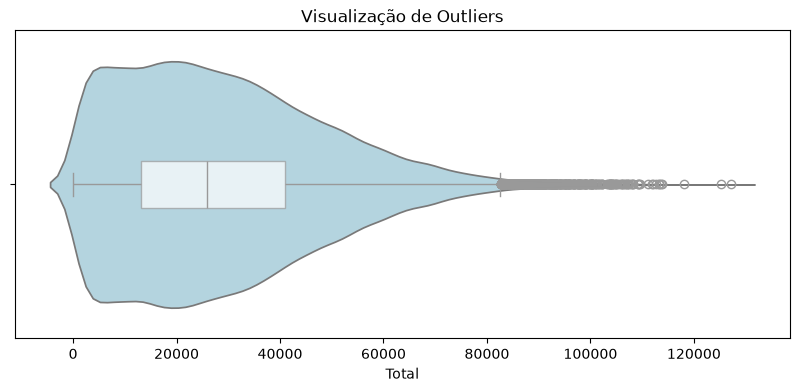

In [22]:
# Exibir gráfico de Violino + gráfico de Caixa para análise de outliers.
plt.figure(figsize=(10, 4))

sns.violinplot(x=orders["total"], color="lightblue", inner=None)

sns.boxplot(x=orders["total"], width=0.15, color="White", boxprops=dict(alpha=0.7))

plt.title("Visualização de Outliers")
plt.xlabel("Total")
plt.show()

## Problema Nº 3 - Presença de Outliers
* Existem dados que expressam comportamento fora da curva, sendo necessário rever uma análise.

In [24]:
# Verificando a existência de dados duplicados.
orders.duplicated().sum()

np.int64(0)

In [28]:
# Verificar todas as datas 
columns = ["placed_at", "created_at", "updated_at"]
ordersDate = orders[columns].apply(pd.to_datetime)

ordersDate = ordersDate.sort_values(by="created_at", ascending=False)
ordersDate.head(1000)

,placed_at,created_at,updated_at
40590,2026-12-31 23:43:09,2026-12-31 23:43:09,2026-12-31 23:43:09
6981,2026-12-31 22:05:26,2026-12-31 22:05:26,2026-12-31 22:05:26
25182,2026-12-31 21:59:40,2026-12-31 21:59:40,2026-12-31 21:59:40
33613,2026-12-31 21:59:25,2026-12-31 21:59:25,2026-12-31 21:59:25
7985,2026-12-31 21:54:41,2026-12-31 21:54:41,2026-12-31 21:54:41
...,...,...,...
38143,2026-12-09 09:02:20,2026-12-09 09:02:20,2026-12-09 09:02:20
48658,2026-12-09 09:01:32,2026-12-09 09:01:32,2026-12-09 09:01:32
46385,2026-12-09 08:44:08,2026-12-09 08:44:08,2026-12-09 08:44:08
20834,2026-12-09 08:24:41,2026-12-09 08:24:41,2026-12-09 08:24:41
